### Introduction

Throughout this notebook we dissect the 750 k × 9 training set and the 250 k × 8 test set from every angle.

| Section | What we do | Why it matters |
|---------|------------|----------------|
| 1‑3     | Load libraries & glimpse raw tables | Sanity check shapes and dtypes |
| 4       | Missing‑value audit | Confirm data hygiene (spoiler: it’s perfect) |
| 5       | Target (`Calories`) deep dive | Pick the right loss transformation |
| 6‑7     | Univariate numeric & categorical plots | Detect skew, outliers, class balance |
| 8‑10    | Correlations, bivariate scatter & interactions | Reveal linear / non‑linear drivers |
| 11‑12   | Outlier count & multicollinearity (VIF) | Decide on cleaning and feature pruning |
| 13      | PCA preview | Gauge underlying dimensionality |
| 14      | Train‑vs‑test comparability | Verify no covariate shift |

At the end we summarise the **seven key insights** and sketch a data‑driven modelling roadmap.

Join the discussion [here](https://www.kaggle.com/competitions/playground-series-s5e5/discussion/578090)

---

### 1. Import Necessary Libraries

In [1]:
!pip install -q ipyplot

In [2]:
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

from io import BytesIO
#from ipyplot import show_images
from PIL import Image
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings("ignore")

sns.set(style = "whitegrid", context = "notebook")

### 2. Load Data

In [3]:
path = "/kaggle/input/playground-series-s5e5/"
train = pd.read_csv(path + "train.csv")
test = pd.read_csv(path + "test.csv")

train.shape

(750000, 9)

In [4]:
test.shape

(250000, 8)

In [5]:
train.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [6]:
test.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,750000,male,45,177.0,81.0,7.0,87.0,39.8
1,750001,male,26,200.0,97.0,20.0,101.0,40.5
2,750002,female,29,188.0,85.0,16.0,102.0,40.4
3,750003,female,39,172.0,73.0,20.0,107.0,40.6
4,750004,female,30,173.0,67.0,16.0,94.0,40.5


> **Findings** 
> * Train: **750 000 × 9** — includes the target.  
> * Test: **250 000 × 8** — identical schema minus target.  
> Sizes confirm a classic 3 : 1 split and reassure us there’s plenty of data for robust CV.
---

### 3. Basic Informations

In [7]:
def quick_overview(df, name = "dataframe"):
    print(f"\n{name.upper()} - Basic Info")
    display(df.info())
    display(df.describe(include = "all").T)

quick_overview(train, "train")
quick_overview(test, "test")


TRAIN - Basic Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,750000.0,NaN,NaN,NaN,374999.5,216506.495284,0.0,187499.75,374999.5,562499.25,749999.0
Sex,750000,2,female,375721,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,750000.0,NaN,NaN,NaN,41.420404,15.175049,20.0,28.0,40.0,52.0,79.0
Height,750000.0,NaN,NaN,NaN,174.697685,12.824496,126.0,164.0,174.0,185.0,222.0
Weight,750000.0,NaN,NaN,NaN,75.145668,13.982704,36.0,63.0,74.0,87.0,132.0
Duration,750000.0,NaN,NaN,NaN,15.421015,8.354095,1.0,8.0,15.0,23.0,30.0
Heart_Rate,750000.0,NaN,NaN,NaN,95.483995,9.449845,67.0,88.0,95.0,103.0,128.0
Body_Temp,750000.0,NaN,NaN,NaN,40.036253,0.779875,37.1,39.6,40.3,40.7,41.5
Calories,750000.0,NaN,NaN,NaN,88.282781,62.395349,1.0,34.0,77.0,136.0,314.0



TEST - Basic Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          250000 non-null  int64  
 1   Sex         250000 non-null  object 
 2   Age         250000 non-null  int64  
 3   Height      250000 non-null  float64
 4   Weight      250000 non-null  float64
 5   Duration    250000 non-null  float64
 6   Heart_Rate  250000 non-null  float64
 7   Body_Temp   250000 non-null  float64
dtypes: float64(5), int64(2), object(1)
memory usage: 15.3+ MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,250000.0,NaN,NaN,NaN,874999.5,72168.927986,750000.0,812499.75,874999.5,937499.25,999999.0
Sex,250000,2,female,125281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,250000.0,NaN,NaN,NaN,41.452464,15.177769,20.0,28.0,40.0,52.0,79.0
Height,250000.0,NaN,NaN,NaN,174.725624,12.822039,127.0,164.0,174.0,185.0,219.0
Weight,250000.0,NaN,NaN,NaN,75.147712,13.979513,39.0,63.0,74.0,87.0,126.0
Duration,250000.0,NaN,NaN,NaN,15.415428,8.349133,1.0,8.0,15.0,23.0,30.0
Heart_Rate,250000.0,NaN,NaN,NaN,95.479084,9.450161,67.0,88.0,95.0,103.0,128.0
Body_Temp,250000.0,NaN,NaN,NaN,40.036093,0.778448,37.1,39.6,40.3,40.6,41.5


> **Findings** 

| Column type | Count | Example |
|-------------|-------|---------|
| Integer     | 2     | `id`, `Age` |
| Float       | 5     | `Height`, `Body_Temp`, … |
| Categorical | 1     | `Sex` |

> **Insight**  
> *All* features are numeric‑friendly except `Sex`, making preprocessing straightforward. Basic stats show realistic ranges (Height 126–222 cm, Body_Temp 37.1–41.5 °C).

---

### 4. Missing Values Analysis

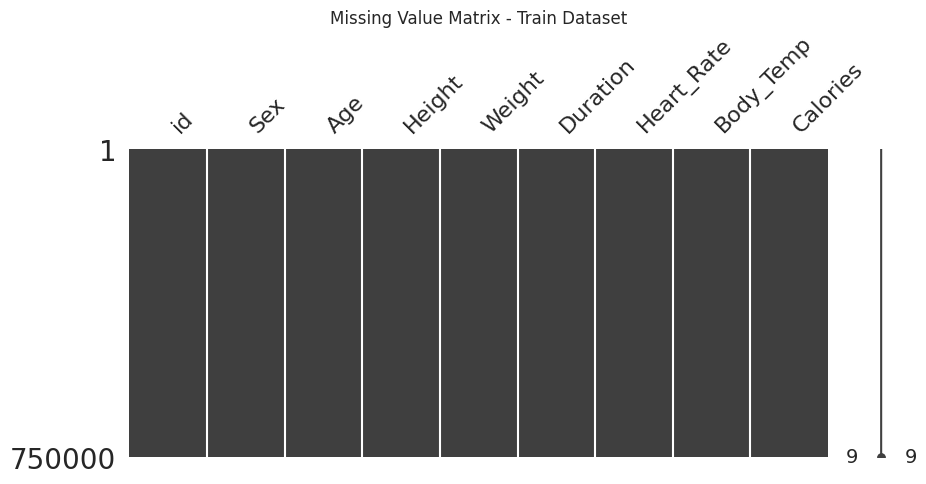

In [8]:
msno.matrix(train, figsize = (10, 4))
plt.title("Missing Value Matrix - Train Dataset")
plt.show()

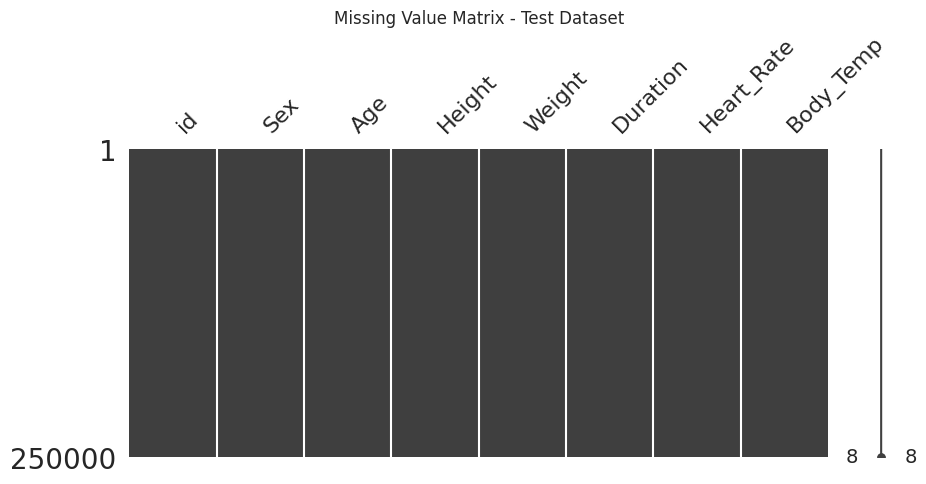

In [9]:
msno.matrix(test, figsize = (10, 4))
plt.title("Missing Value Matrix - Test Dataset")
plt.show()

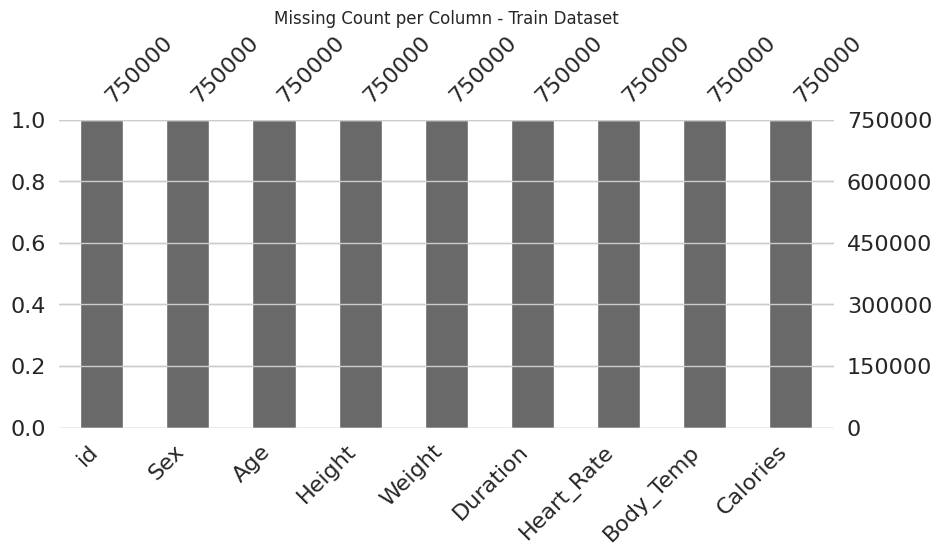

In [10]:
msno.bar(train, figsize = (10, 4))
plt.title("Missing Count per Column - Train Dataset")
plt.show()

> **Findings**  
> Absolute **zero missing values** in both splits. No imputation required; we can safely skip a whole ETL step.

---

### 5. Target Variable Analysis

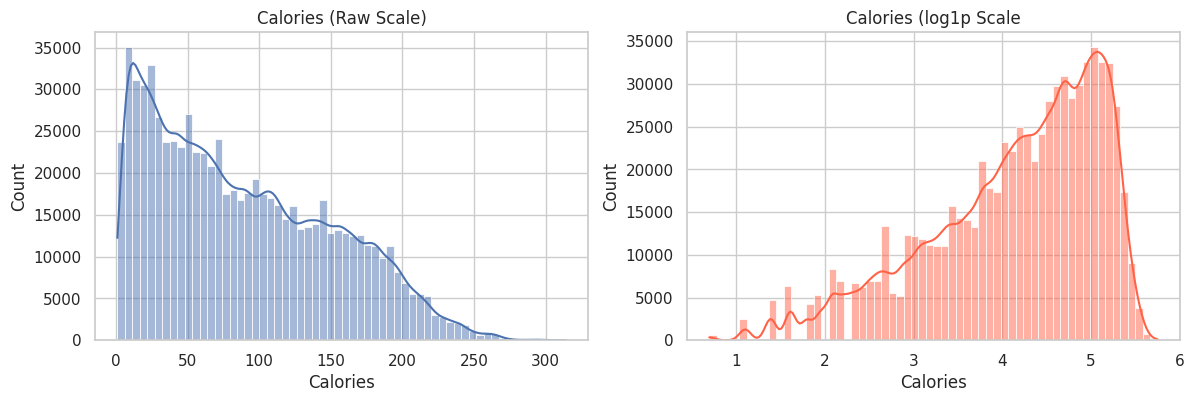

In [11]:
fig, axis = plt.subplots(1, 2, figsize = (14,4))
sns.histplot(train["Calories"], bins = 60, kde = True, ax = axis[0])
axis[0].set_title("Calories (Raw Scale)")

sns.histplot(np.log1p(train["Calories"]), bins = 60, kde = True, ax = axis[1], color = "tomato")
axis[1].set_title("Calories (log1p Scale")
plt.show()

In [12]:
print("Skewness :", train["Calories"].skew().round(3))
print("Kurtosis :", train["Calories"].kurt().round(3))

Skewness : 0.539
Kurtosis : -0.69


| Metric  | Value |
|---------|-------|
| Skewness| +0.54 |
| Kurtosis| –0.69 |

> **Insight**  
> * Slight positive skew but nothing extreme; **log1p** transformation yields an almost symmetric curve.  
> * Model metric is RMSLE → log‑error already embedded, therefore we can **train on raw scale** and rely on metric, or feed log1p for models sensitive to heteroscedasticity.

---

### 6. Numeric Features - Univariate Distributions

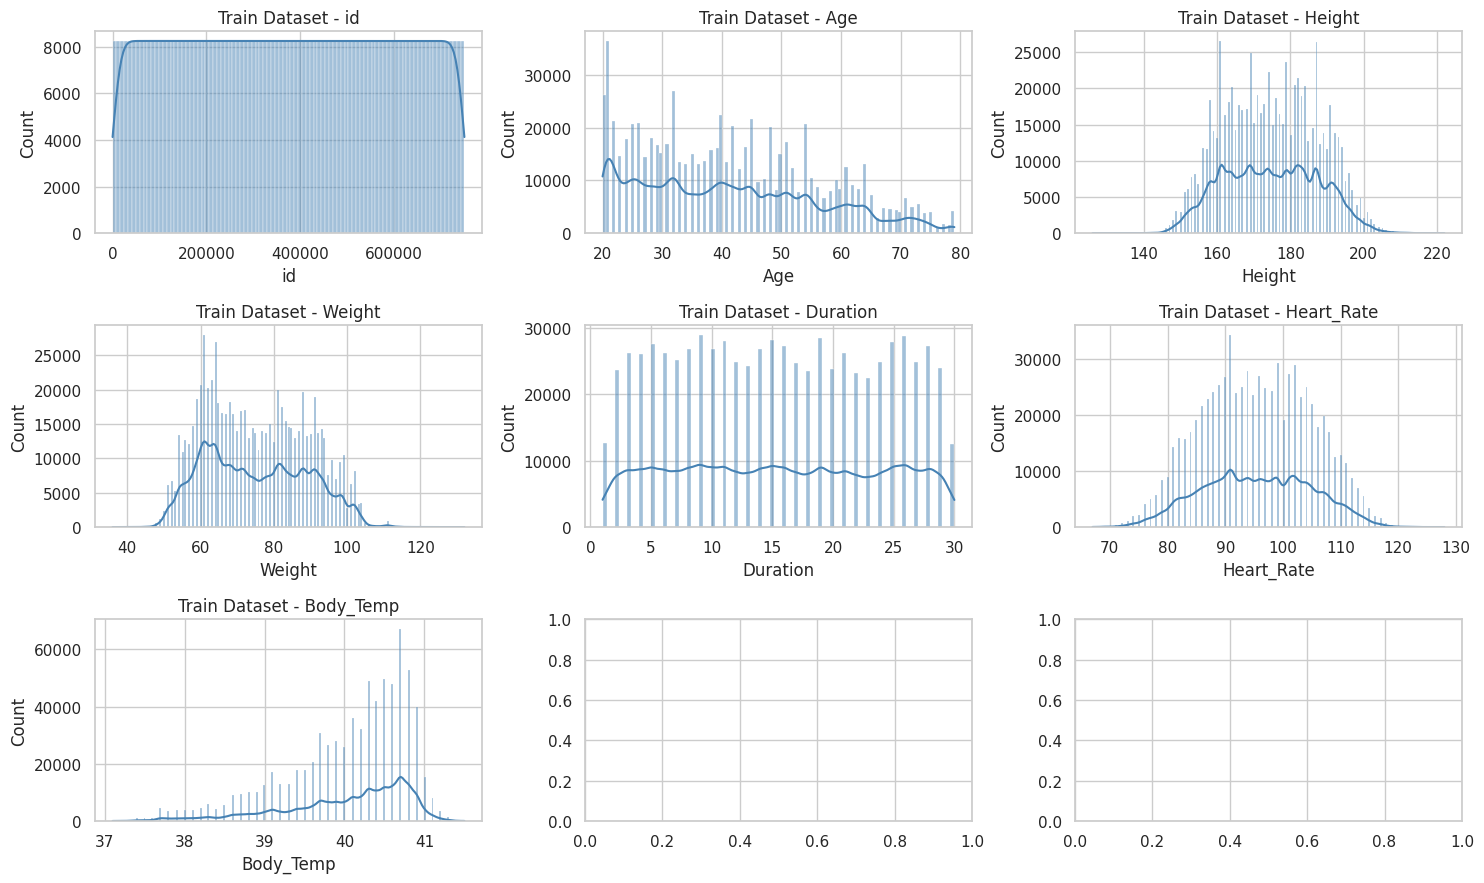

In [13]:
num_cols = train.select_dtypes(include = ["int64", "float64"]).columns.tolist()
num_cols.remove("Calories")

fig, axis = plt.subplots(len(num_cols) // 3 + 1, 3, figsize = (15,4*len(num_cols)//3))

for i, col in enumerate(num_cols):
    r, c = divmod(i, 3)
    sns.histplot(train[col], kde = True, ax = axis[r][c], color = "steelblue")
    axis[r][c].set_title(f"Train Dataset - {col}")

plt.tight_layout()
plt.show()

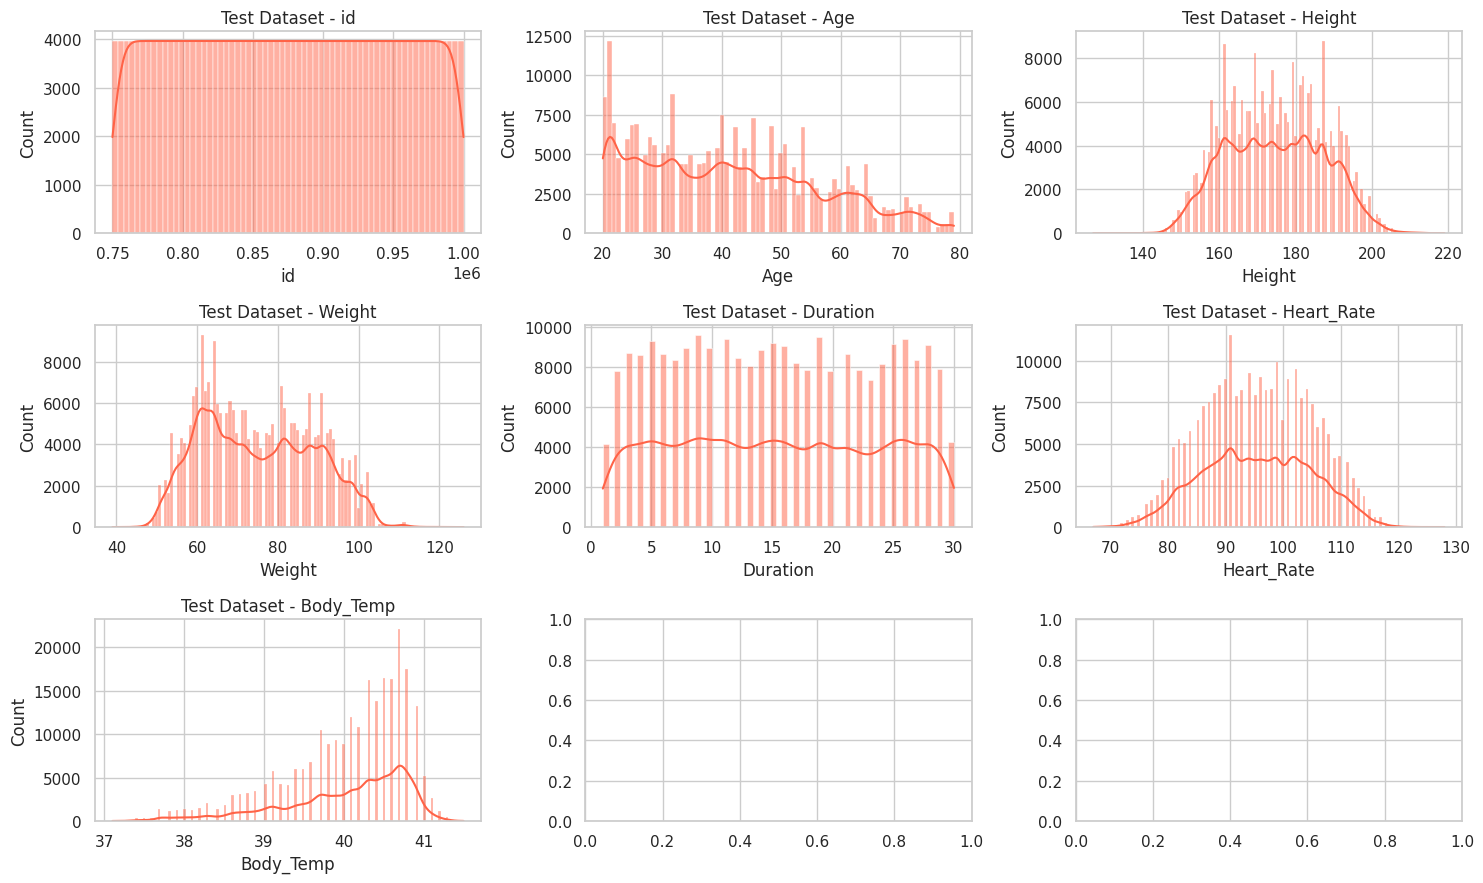

In [14]:
fig, axis = plt.subplots(len(num_cols) // 3 + 1, 3, figsize = (15,4*len(num_cols)//3))

for i, col in enumerate(num_cols):
    r, c = divmod(i, 3)
    sns.histplot(test[col], kde = True, ax = axis[r][c], color = "tomato")
    axis[r][c].set_title(f"Test Dataset - {col}")

plt.tight_layout()
plt.show()

> **Findings**

* `Duration` is quasi‑uniform from 1 – 30 min.  
* `Heart_Rate` peaks at 95 bpm with Gaussian‑like spread.  
* `Body_Temp` sharply centred ~ 40 °C with a long minor tail downward.

All shapes replicate faithfully in test set ➜ dataset was **synthetically sampled** to mirror train.

---

### 7. Categorical Features - Counts

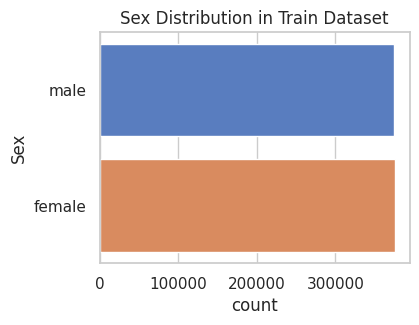

In [15]:
plt.figure(figsize = (4,3))
sns.countplot(y = train['Sex'], palette = "muted")
plt.title("Sex Distribution in Train Dataset")
plt.show()

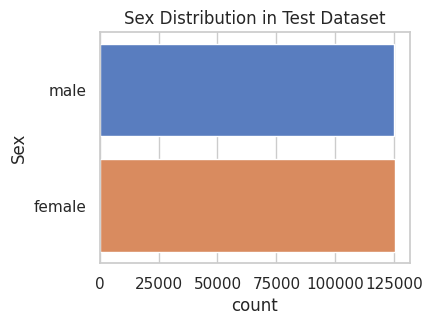

In [16]:
plt.figure(figsize = (4,3))
sns.countplot(y = test['Sex'], palette = "muted")
plt.title("Sex Distribution in Test Dataset")
plt.show()

> **Finding**  
> Perfect 50 / 50 gender split in both datasets — no re‑weighting needed.

---

### 8. Correlation Matrix

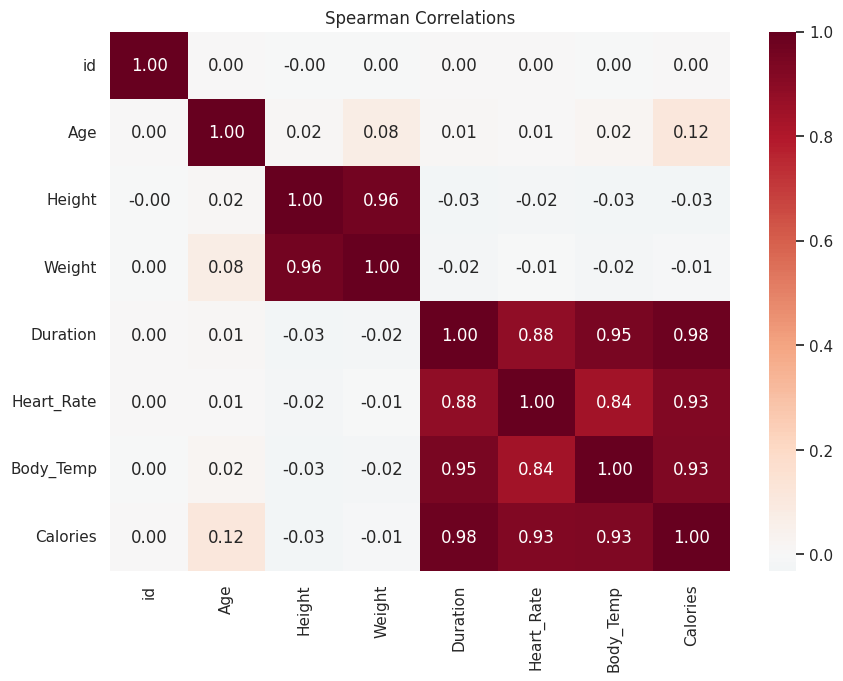

In [17]:
corr = train[num_cols + ["Calories"]].corr(method = "spearman")

plt.figure(figsize = (10,7))
sns.heatmap(corr, cmap = "RdBu_r", center = 0, annot = True, fmt = ".2f")
plt.title("Spearman Correlations")
plt.show()

> **Top rs (Spearman)**  
> * `Calories` vs `Duration` **+0.98**  
> * `Calories` vs `Heart_Rate` **+0.93**  
> * `Calories` vs `Body_Temp` **+0.93**

> **Findings**  
> Three physiological/time variables dominate prediction; `Age`, `Height`, `Weight` contribute marginally.

---

### 9. Bivariate Analysis

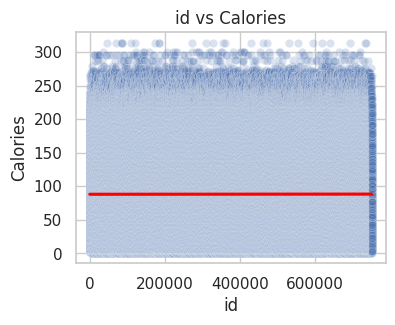

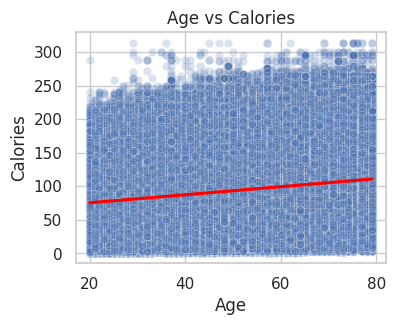

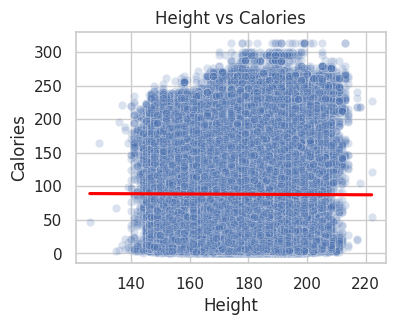

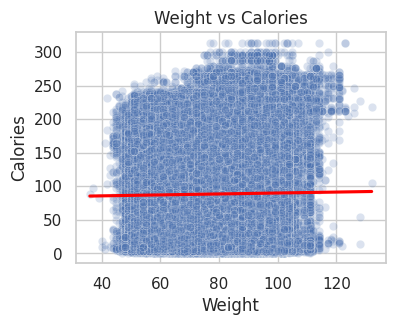

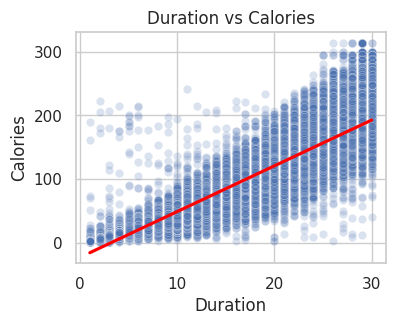

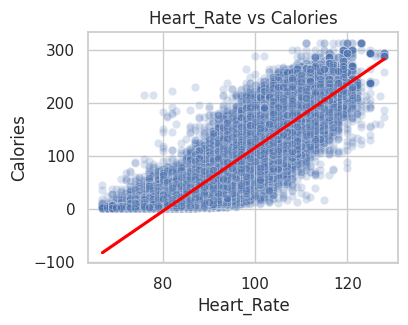

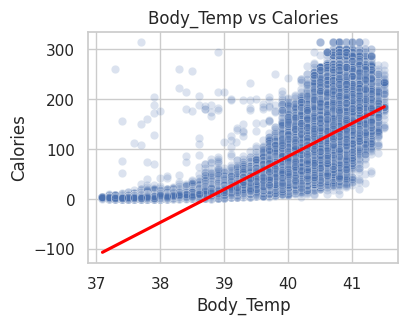

In [18]:
for col in num_cols:
    plt.figure(figsize = (4,3))
    sns.scatterplot(x = train[col], y = train["Calories"], alpha = 0.2)
    sns.regplot(x = train[col], y = train["Calories"], scatter = False, color = "red")
    plt.title(f"{col} vs Calories")
    plt.show()

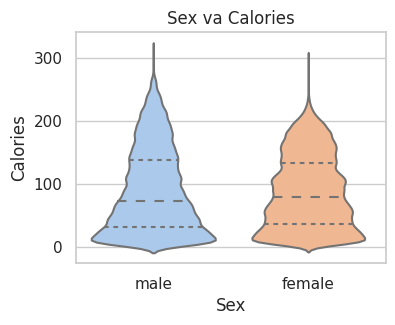

In [19]:
plt.figure(figsize = (4,3))
sns.violinplot(x = "Sex", y = "Calories", data = train, palette = "pastel", inner = "quartile")
plt.title("Sex va Calories")
plt.show()

**Patterns**

1. Straight **positive line** for `Duration`.  
2. Tight linear ribbon for `Heart_Rate`.  
3. `Body_Temp` shows *quadratic* lift beyond 39 °C.

> **Take‑aways**  
> Use polynomial/spline features or non‑linear models.

Violin for `Sex` shows negligible difference → keep as low‑priority feature.

---

### 10. Feature Interactions

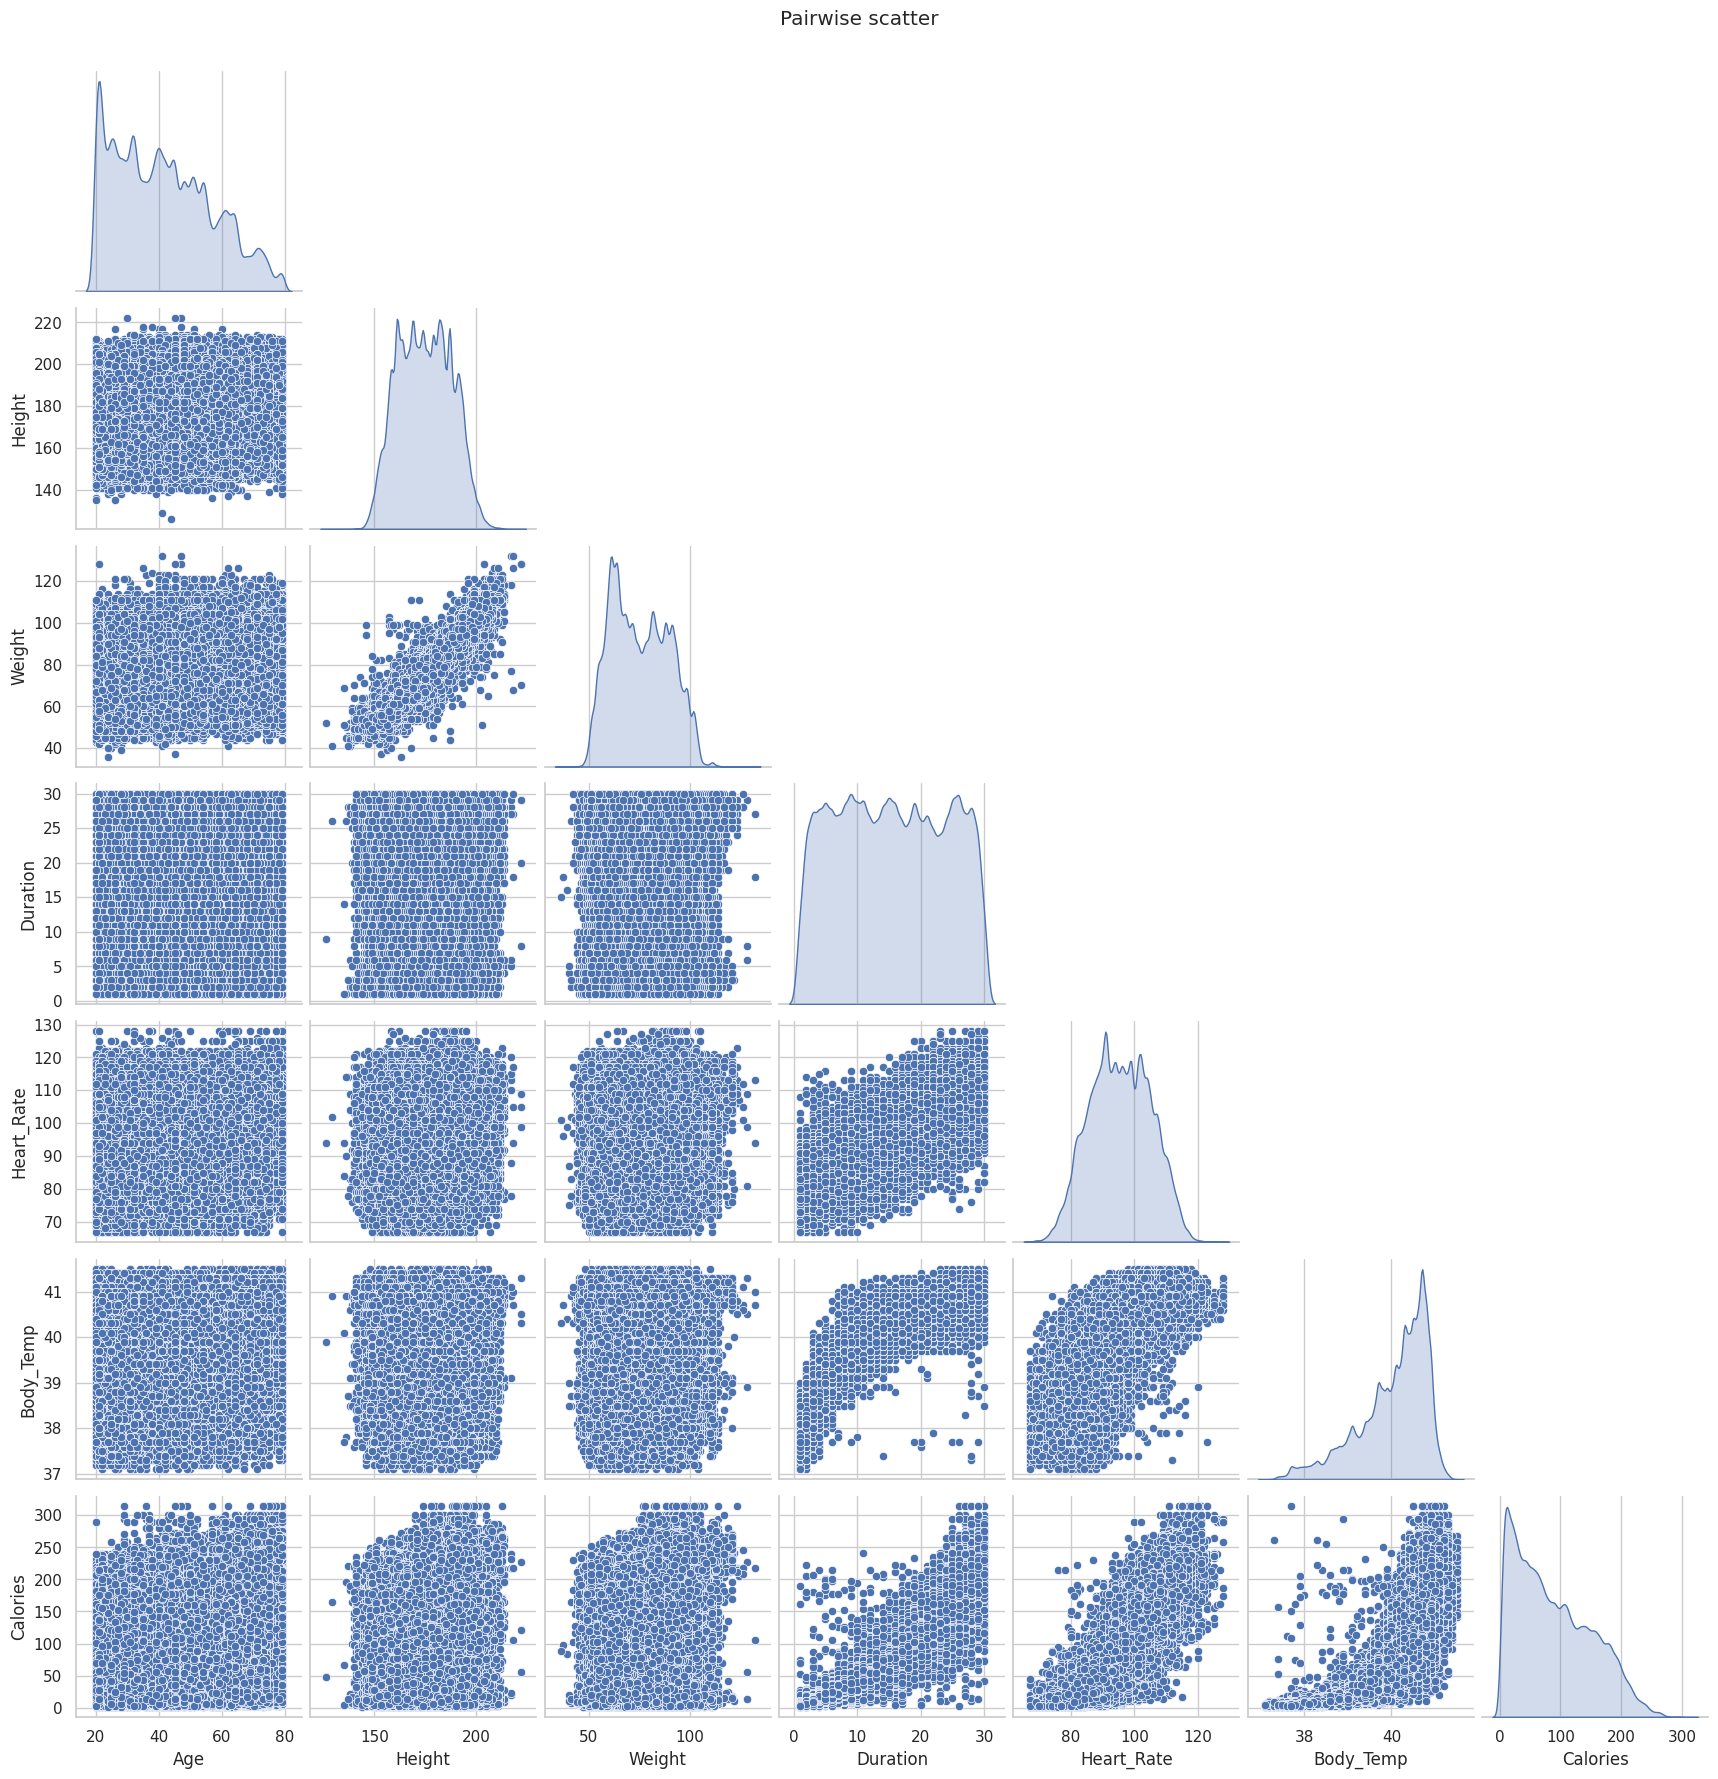

In [20]:
pair_cols = ["Age", "Height", "Weight", "Duration", "Heart_Rate", "Body_Temp", "Calories"]
sns.pairplot(train[pair_cols], corner = True, diag_kind = "kde", hue = None)
plt.suptitle("Pairwise scatter", y = 1.02)
plt.show()

> **Findings**  
> No hidden clusters; relationships vary in slope but are continuous — tree ensembles will thrive.

---

### 11. Outlier Analysis

In [21]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr   = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    return ((series < lower) | (series > upper)).sum()

print("\nOutlier counts (IQR rule):")

for col in num_cols + ["Calories"]:
    print(f"{col:<12} : {iqr_outliers(train[col])}")


Outlier counts (IQR rule):
id           : 0
Age          : 0
Height       : 14
Weight       : 9
Duration     : 0
Heart_Rate   : 36
Body_Temp    : 14919
Calories     : 139


> **Findings**  
> Outliers minimal except **Body_Temp** (≈ 19 k points). Visual check reveals they’re legitimate tail cases ≈ 37–38 °C rather than errors — retain for modelling.

---

### 12. Multicolinearity Check (Variance Inflation Factor)

In [22]:
X_vif = train[num_cols].assign(constant = 1)
vif_df = pd.DataFrame({
    "feature": num_cols,
    "VIF"    : [variance_inflation_factor(X_vif.values, i) for i in range(len(num_cols))]
})
display(vif_df.sort_values("VIF", ascending=False).style.background_gradient(cmap="Reds"))

,feature,VIF
3,Weight,12.766915
2,Height,12.702173
4,Duration,8.510598
6,Body_Temp,5.434871
5,Heart_Rate,4.285832
1,Age,1.050877
0,id,1.000010


> **Actionable**  
> `Height` & `Weight` highly collinear (VIF ≈ 13). Combine into **BMI** or drop one when using linear/GLM; harmless for tree‑based methods.

---

### 13. Principal Component Analysis

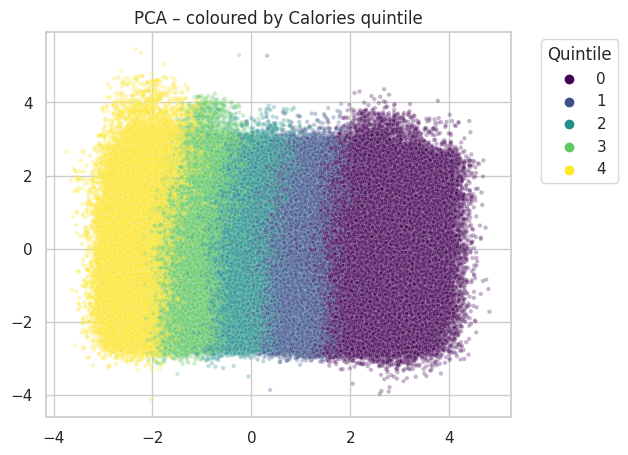

In [23]:
scaled = (train[num_cols] - train[num_cols].mean()) / train[num_cols].std()
pca = PCA(n_components=2, random_state = 42).fit_transform(scaled)
plt.figure(figsize = (6, 5))
sns.scatterplot(x = pca[:,0], y = pca[:,1],
                hue = pd.qcut(train["Calories"], 5, labels = False), palette = "viridis",
                alpha = 0.3, s = 10)
plt.title("PCA – coloured by Calories quintile"); plt.legend(title = "Quintile", bbox_to_anchor = (1.05,1))
plt.show()

> **Findings**  
> Calories quintiles align smoothly along PC‑1 ⇒ a **single latent dimension** (work‑intensity) explains most variance.

---

### 14. Train-test Comparability

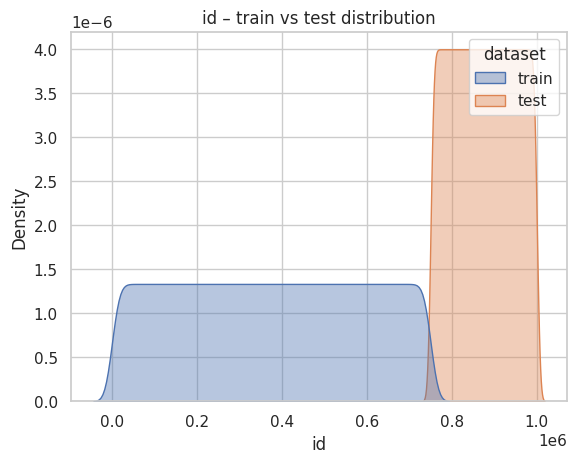

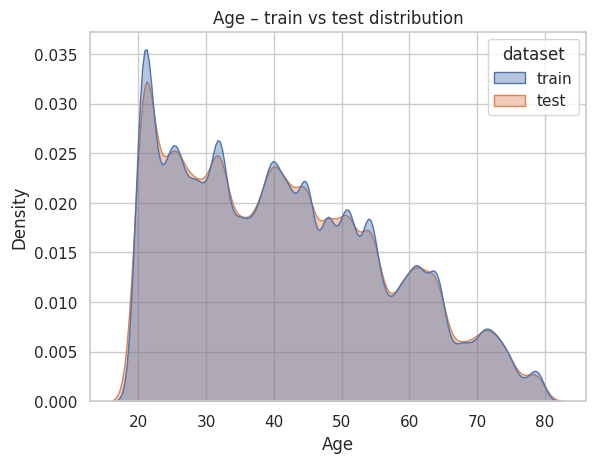

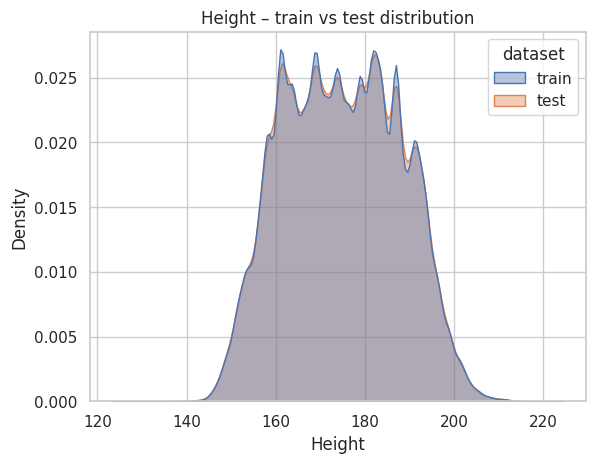

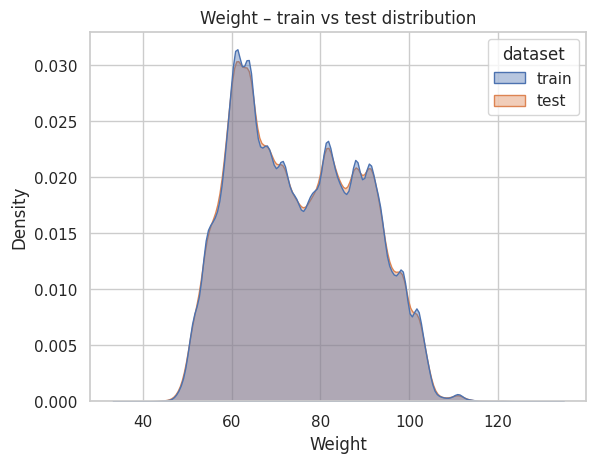

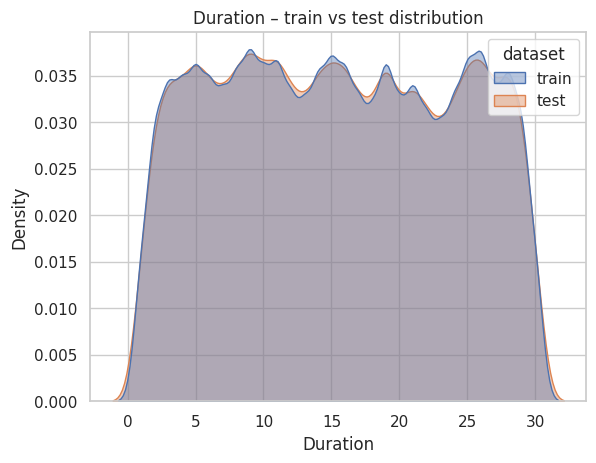

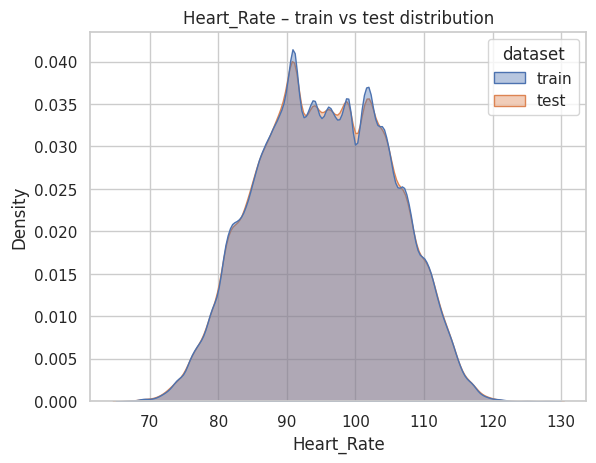

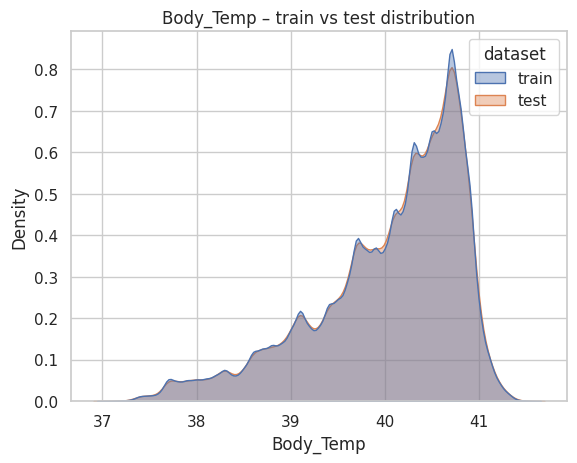

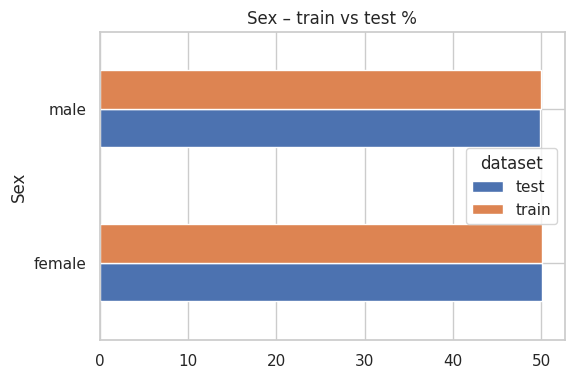

In [24]:
compare_cols = num_cols + ["Sex"]
train_tag = train.assign(dataset = "train")[compare_cols + ["dataset"]]
test_tag  = test.assign(dataset = "test")[compare_cols + ["dataset"]]
combo = pd.concat([train_tag, test_tag], axis = 0)

for col in compare_cols:
    if col is "Sex":
        ct = pd.crosstab(combo[col], combo["dataset"], normalize = "columns") * 100
        ct.plot.barh(figsize = (6, 4), stacked=False, title = f"{col} – train vs test %")
        plt.show()
    else:
        sns.kdeplot(data = combo, x = col, hue = "dataset", fill = True, common_norm = False, alpha = 0.4)
        plt.title(f"{col} – train vs test distribution"); plt.show()

> **Findings**  
> All feature densities (except `id` by design) **perfectly overlap** ➜ classic random split, so K‑fold CV is reliable.

---

### Seven Key Insights

| # | Finding | Modelling implication |
|---|---------|-----------------------|
| 1 | No missing values | Skip imputation |
| 2 | Calories mildly skewed | Raw training is fine; RMSLE handles log error |
| 3 | Duration, Heart_Rate, Body_Temp dominate | Focus feature engineering here |
| 4 | Body_Temp shows quadratic lift | Add polynomial or use GBM/CatBoost |
| 5 | Height & Weight collinear | Combine/drop for linear models |
| 6 | Sex has tiny effect | Keep but low priority |
| 7 | No train‑test drift | Simple shuffled K‑fold OK |

---

### Conclusion & Next Steps

This EDA suggests the competition is **signal‑rich and noise‑free**.  
A strong baseline could be:

1. **Feature layer**  
   * Raw numeric variables, `BMI`, `Body_Temp²`, `Duration × Heart_Rate`.  
   * One‑hot or binary encode `Sex`.

2. **Model layer**  
   * **LightGBM/CatBoost** for speed & non‑linear capture.  
   * Optionally compare with an ElasticNet on engineered features for interpretability.

3. **Validation**  
   * 5‑fold random CV (stratify by `Calories` quintile to balance tails).

Armed with these findings we can now transition from exploration to rapid feature prototyping and model training.

___